In [1]:
import pandas as pd
import numpy as np
import os
import sys

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

In [2]:
data_train = pd.read_csv(
    "../../../dataset/Spotify_train_preprocesado_regresion.csv"
)

data_test = pd.read_csv(
    "../../../dataset/Spotify_test_preprocesado_regresion.csv"
)

df_train = data_train.copy()
df_test = data_test.copy()

print("Dataset de entrenamiento:")
display(df_train.head())

print("\nDataset de prueba:")
display(df_test.head())


Dataset de entrenamiento:


,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.360656,0.407609,0.005418,...,-0.557598,0.751125,-0.804229,0.532848,-0.562123,-0.436477,1.542740,-0.147610,-0.695300,21.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.360656,0.100464,-0.034422,...,-0.017461,0.751125,-0.785413,0.623235,-0.606882,-0.678120,1.183864,0.437714,-0.191994,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.927115,-1.881489,0.216573,...,0.430609,0.751125,-0.519639,-0.618079,-0.580263,-0.985860,-1.305115,0.437984,0.625209,45.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.360656,1.746296,0.336094,...,0.571210,-1.331337,-0.500823,-0.710274,-0.606882,-0.635477,-0.506326,0.064335,-0.879964,4.0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.360656,0.726344,-1.795371,...,-2.390784,-1.331337,1.124396,1.430692,1.793755,-0.671013,1.195440,2.664353,-0.772929,55.0



Dataset de prueba:


,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.927115,-1.452645,-1.914892,...,-2.318107,0.751125,-0.700742,1.813330,1.793755,-0.700153,-1.619613,-0.133029,1.330330,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.360656,1.798453,0.626930,...,1.478109,0.751125,0.865678,-0.675324,-0.606764,1.390062,1.450127,-0.406397,-0.528812,1.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.360656,0.639416,0.224541,...,0.842404,0.751125,-0.199770,-0.940037,-0.606785,-0.724317,1.303489,2.353574,-0.550148,7.0
3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,-1.648427,-0.067596,0.754419,...,0.438615,0.751125,2.126046,1.707878,-0.606882,2.409939,0.292462,-1.350621,-1.566635,23.0
4,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.927115,0.830657,1.093063,...,1.257701,0.751125,-0.380872,-0.942719,1.793755,-1.048403,1.006355,0.096426,1.158399,0.0


In [3]:
# Separación de variables predictoras y objetivo
X_train = df_train.drop(
    columns=["popularity"]
)

y_train = df_train[
    "popularity"
]

X_test = df_test.drop(
    columns=["popularity"]
)

y_test = df_test[
    "popularity"
]

In [4]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

modelo_arbol = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

scores_arbol = cross_validate(
    modelo_arbol,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

resultados_arbol = {
    "MAE": -scores_arbol["test_mae"].mean(),
    "MSE": -scores_arbol["test_mse"].mean(),
    "RMSE": -scores_arbol["test_rmse"].mean(),
    "R2": scores_arbol["test_r2"].mean()
}

desviaciones_arbol = {
    "MAE": scores_arbol["test_mae"].std(),
    "MSE": scores_arbol["test_mse"].std(),
    "RMSE": scores_arbol["test_rmse"].std(),
    "R2": scores_arbol["test_r2"].std()
}

print("Resultados de Decision Tree Regressor:")

for metrica, valor in resultados_arbol.items():
    print(f"{metrica}: {valor:.4f}")

print("\nDesviación estándar entre particiones:")

for metrica, valor in desviaciones_arbol.items():
    print(f"{metrica}: {valor:.4f}")

Resultados de Decision Tree Regressor:
MAE: 14.1420
MSE: 381.4502
RMSE: 19.5306
R2: 0.2310

Desviación estándar entre particiones:
MAE: 0.1869
MSE: 2.6665
RMSE: 0.0683
R2: 0.0044


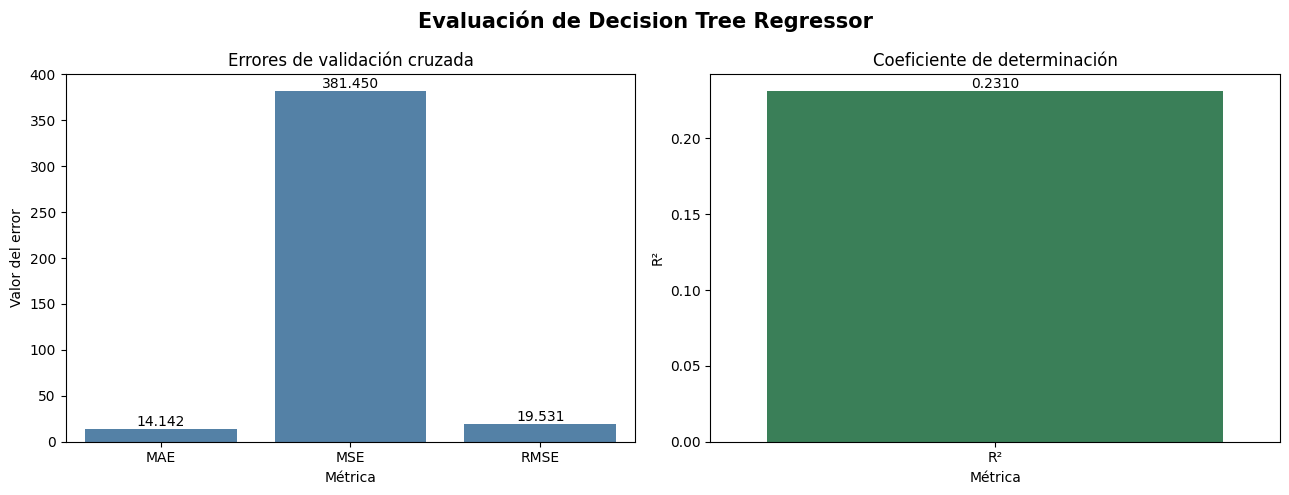

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metricas_error = ["MAE", "MSE", "RMSE"]

valores_error = [
    resultados_arbol[m]
    for m in metricas_error
]

sns.barplot(
    x=metricas_error,
    y=valores_error,
    ax=axes[0],
    color="steelblue"
)

axes[0].set_title("Errores de validación cruzada")
axes[0].set_xlabel("Métrica")
axes[0].set_ylabel("Valor del error")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f")

sns.barplot(
    x=["R²"],
    y=[resultados_arbol["R2"]],
    ax=axes[1],
    color="seagreen"
)

axes[1].set_title("Coeficiente de determinación")
axes[1].set_xlabel("Métrica")
axes[1].set_ylabel("R²")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.4f")

plt.suptitle(
    "Evaluación de Decision Tree Regressor",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [7]:
modelo_arbol.fit(X_train, y_train)

print("Modelo entrenado correctamente.")
print("Profundidad del árbol:", modelo_arbol.get_depth())
print("Cantidad de hojas:", modelo_arbol.get_n_leaves())

Modelo entrenado correctamente.
Profundidad del árbol: 10
Cantidad de hojas: 929


In [8]:
y_pred_arbol = modelo_arbol.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred_arbol)
mse_test = mean_squared_error(y_test, y_pred_arbol)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_arbol)

print("Resultados de Decision Tree Regressor en prueba:")
print(f"MAE:  {mae_test:.4f}")
print(f"MSE:  {mse_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R2:   {r2_test:.4f}")

Resultados de Decision Tree Regressor en prueba:
MAE:  14.1449
MSE:  374.6594
RMSE: 19.3561
R2:   0.2438


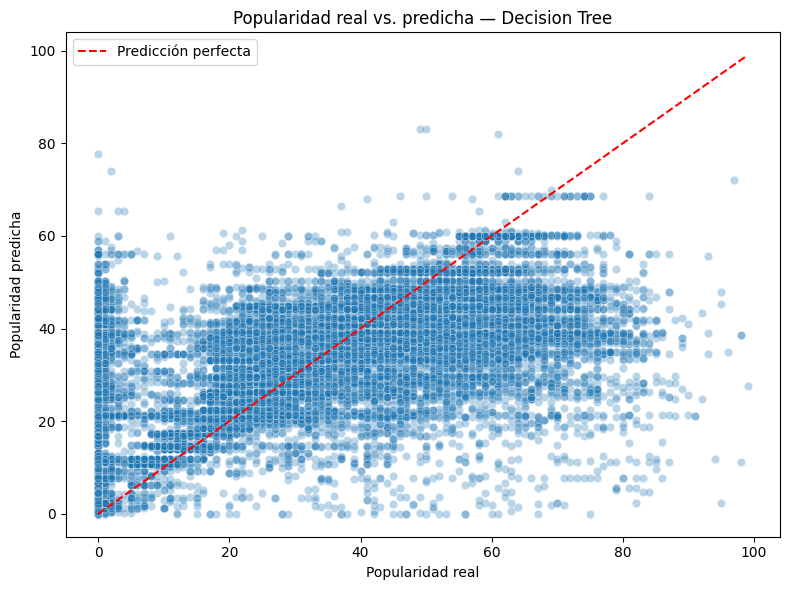

In [9]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_arbol,
    alpha=0.3
)

limite_min = min(y_test.min(), y_pred_arbol.min())
limite_max = max(y_test.max(), y_pred_arbol.max())

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    color="red",
    linestyle="--",
    label="Predicción perfecta"
)

plt.title("Popularidad real vs. predicha — Decision Tree")
plt.xlabel("Popularidad real")
plt.ylabel("Popularidad predicha")
plt.legend()
plt.tight_layout()
plt.show()

,Variable,Importancia
1,bin__track_genre_1,0.114530
4,bin__track_genre_4,0.097426
6,bin__track_genre_6,0.083526
0,bin__track_genre_0,0.073304
9,num__energy,0.063626
2,bin__track_genre_2,0.060853
3,bin__track_genre_3,0.060555
11,num__loudness,0.059690
14,num__acousticness,0.059013
15,num__instrumentalness,0.053500


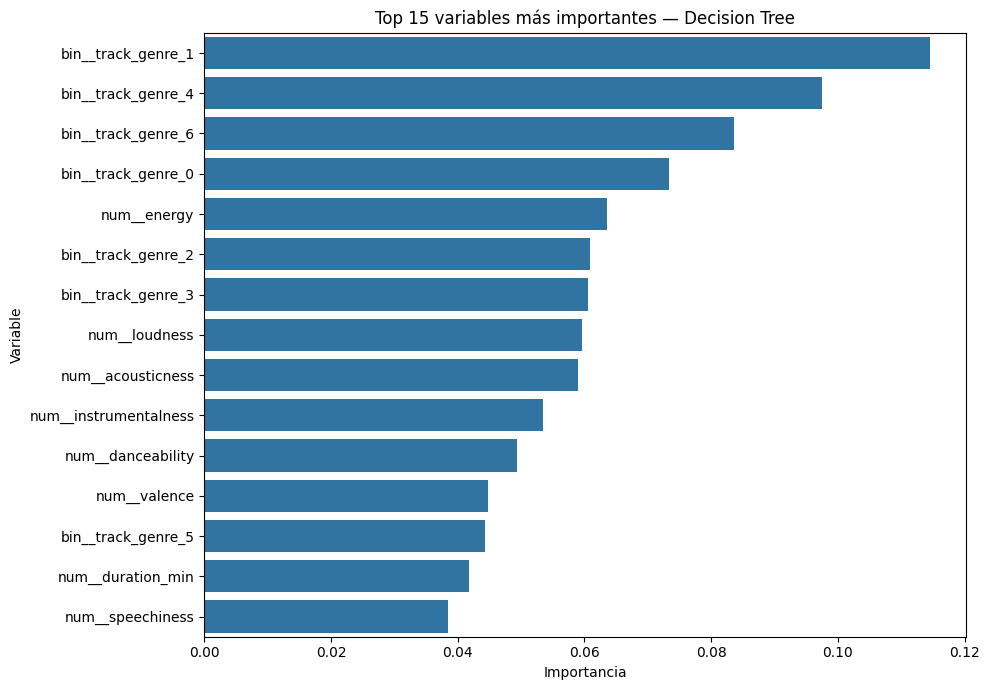

In [10]:
importancias_arbol = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": modelo_arbol.feature_importances_
}).sort_values(
    by="Importancia",
    ascending=False
)

display(importancias_arbol.head(15))

plt.figure(figsize=(10, 7))

sns.barplot(
    data=importancias_arbol.head(15),
    x="Importancia",
    y="Variable"
)

plt.title("Top 15 variables más importantes — Decision Tree")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

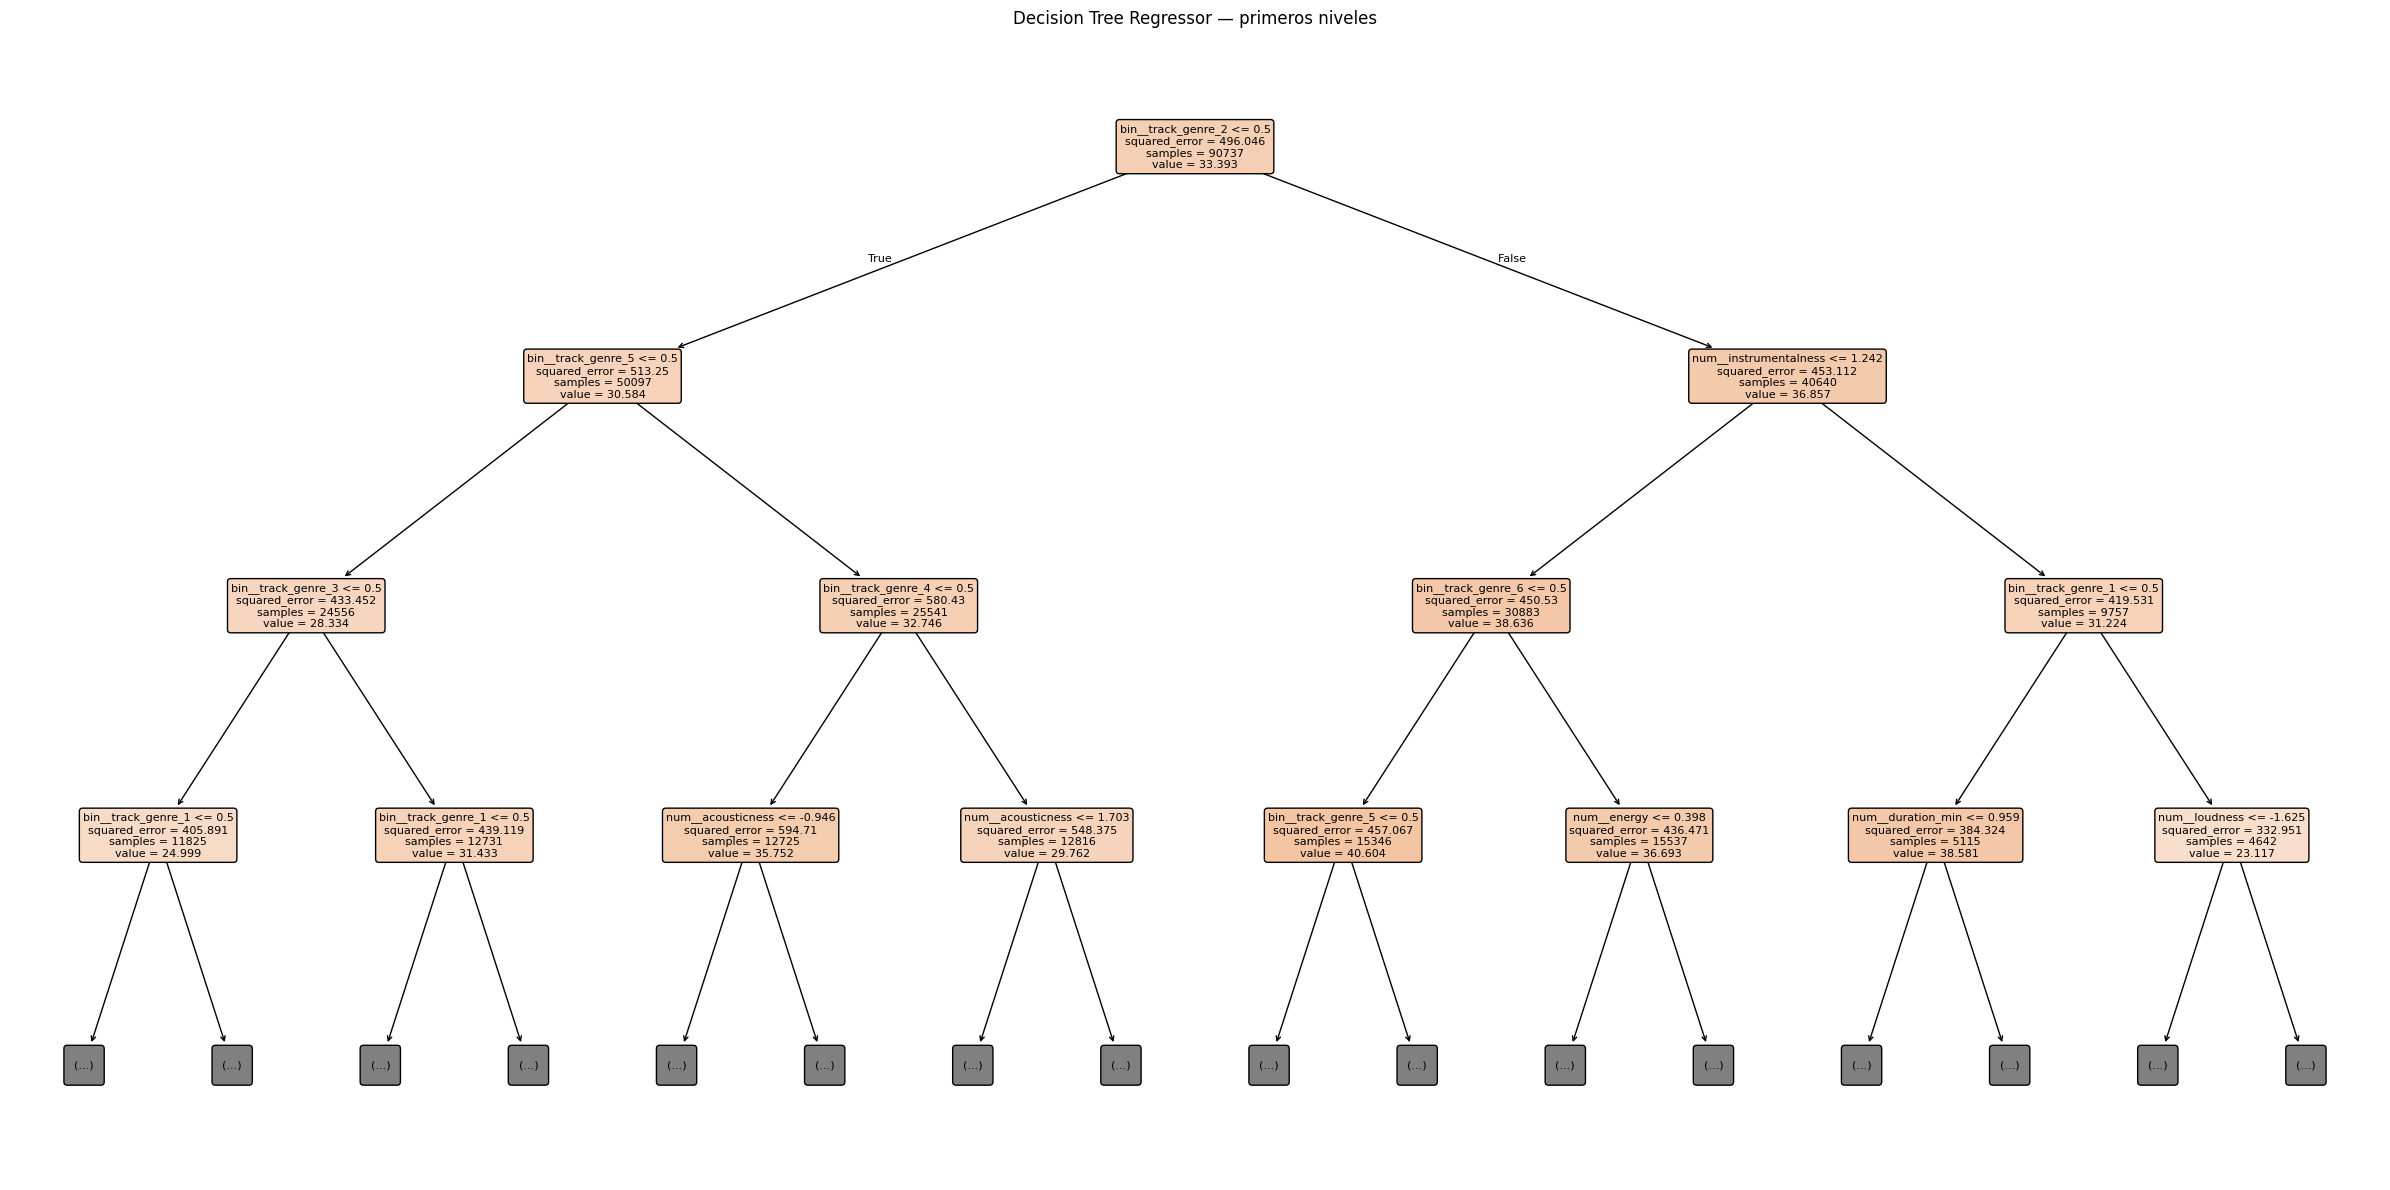

In [11]:
plt.figure(figsize=(24, 12))

plot_tree(
    modelo_arbol,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Regressor — primeros niveles")
plt.tight_layout()
plt.show()